<figure>
<center>
<img src="https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png"/>
</center></figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Inferencia vs Bootstrapping**

In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.stats.api as sms
from scipy import stats
from scipy.stats import bootstrap

# Ejercicios práctico con Datos

## Dataset

In [2]:
# 1. Traer la base de datos
dataset = fetch_ucirepo(id=697)

# 2. Extraer los datos y renombrar la columna de interés
df_poblacion = dataset.data.features[["Curricular units 1st sem (grade)"]].rename(
    columns={"Curricular units 1st sem (grade)": "nota_1er_sem"}
).dropna()

media_poblacional = df_poblacion['nota_1er_sem'].mean()

print("POBLACION")
print(f"Cantidad total de alumnos: {len(df_poblacion)}")
print(f"Media real de la población: {media_poblacional:.2f}")
desc_poblacion = df_poblacion["nota_1er_sem"].describe()
desc_poblacion

POBLACION
Cantidad total de alumnos: 4424
Media real de la población: 10.64


count    4424.000000
mean       10.640822
std         4.843663
min         0.000000
25%        11.000000
50%        12.285714
75%        13.400000
max        18.875000
Name: nota_1er_sem, dtype: float64

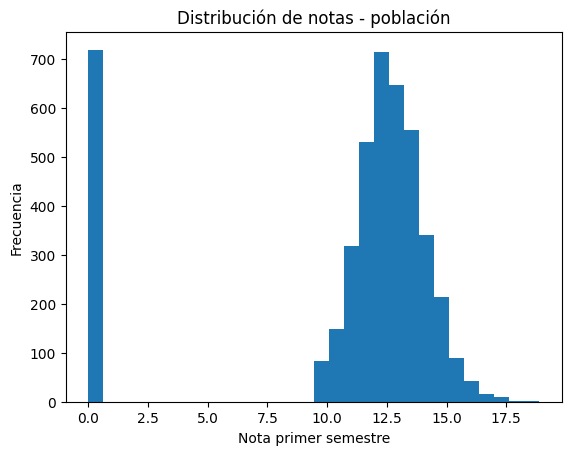

In [3]:
plt.hist(df_poblacion["nota_1er_sem"], bins=30)
plt.xlabel("Nota primer semestre")
plt.ylabel("Frecuencia")
plt.title("Distribución de notas - población")
plt.show()

## Inferencia Clásica

Sea $X$ la calificación obtenida por los estudiantes en el primer semestre, la cual se supone distribuida normalmente.

Se desea determinar el tamaño mínimo de muestra $(n)$ que se debe tomar si se quiere que la probabilidad de que la media muestral sea menor que la media poblacional más un cuarto del desvío estándar sea mayor que 0.95.

Se pide:

Determinar el tamaño mínimo de muestra necesario para cumplir con la precisión requerida

Indicar la fórmula utilizada.

Interpretar el resultado obtenido.

$$
P\!\left(\bar X < \mu + \frac{1}{4}\sigma\right)
=
P\!\left(Z < \frac{\mu+\frac{1}{4}\sigma-\mu}{\sigma/\sqrt{n}}\right)
=
P\!\left(Z < \frac{\sqrt{n}}{4}\right)
$$

$$
\frac{\sqrt{n}}{4}=z_{0.95}=1.645
$$

$$
\sqrt{n}=6.58
$$

$$
n=43.3 \;\Rightarrow\; n=44
$$

es decir, $n$ podría haberse determinado con:

$$
n=(z_{1-\alpha} \cdot k)^2
$$

In [4]:
# --- Definición de parámetros del requisito ---
k = 1/4
confianza = 0.9505

# --- Cálculo del Valor Crítico Z ---
# Obtenemos el valor Z para el 95% de confianza (unilateral)
z = stats.norm.ppf(1 - (1 - confianza))

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z * 1/k)**2
n_final = int(np.ceil(n_exacto))  # Redondeo hacia arriba al entero superior

# --- Respuesta final ---
print(f"RESULTADO: El tamaño de muestra necesario es de {n_final} clientes.")
print(f"Cálculo técnico: n exacto = {n_exacto:.4f}, Z = {z:.3f}")

RESULTADO: El tamaño de muestra necesario es de 44 clientes.
Cálculo técnico: n exacto = 43.5453, Z = 1.650


Para calcular el tamaño muestral usamos $Z$ como aproximación.
Una vez obtenida la muestra, la inferencia final se realizará con $t$ de Student, debido a que desconocemos $\sigma$.

Entonces, sea $X$ la calificación obtenida por los estudiantes, suponiendo que sigue una distribución normal con media poblacional $\mu$ y desvío estándar desconocido.

Previamente se determinó que el tamaño mínimo de muestra necesario es

$$
n = 44
$$

Se toma entonces una muestra aleatoria de $44$ estudiantes y se calculan:

- la media muestral $\bar{x}$
- el desvío estándar muestral $s$

Dado que el desvío poblacional $\sigma$ es desconocido, se utiliza la distribución $t$ de Student.

In [5]:
n = 44
muestra = df_poblacion.sample(n=n, random_state=123)

# estadísticos de la muestra
media_muestral = round(muestra["nota_1er_sem"].mean(), 4)
desvio_muestral = round(muestra["nota_1er_sem"].std(), 4)

print("MUESTRA BASE")
print(f"Cantidad total de alumnos en la muestra: {len(muestra)}")
print(f"Media real de la muestra: {media_muestral}")
print(f"Desvío real de la muestra: {desvio_muestral}")
muestra.describe()

MUESTRA BASE
Cantidad total de alumnos en la muestra: 44
Media real de la muestra: 11.1056
Desvío real de la muestra: 4.144


,nota_1er_sem
count,44.000000
mean,11.105614
std,4.143959
min,0.000000
25%,11.437500
50%,12.373095
75%,13.041667
max,14.666667


A partir de los datos muestrales se obtienen los siguientes estadísticos:

$$
\bar{x} = 12.5893
$$

$$
s = 1.1869
$$

Dado que el desvío estándar poblacional $\sigma$ es desconocido, se utiliza la distribución $t$ de Student.

La variable pivote es

$$
T = \frac{\bar X - \mu}{s/\sqrt{n}}
$$

la cual sigue una distribución

$$
T \sim t_{n-1}
$$

Con $n=44$ los grados de libertad son

$$
df = 43
$$

Para un nivel de confianza del $95\%$ el valor crítico es

$$
t_{0.025,\,43} \approx 2.016
$$

El error estándar de la media es

$$
SE = \frac{s}{\sqrt{n}} = \frac{1.1869}{\sqrt{44}} \approx 0.179
$$

El margen de error es

$$
ME = t_{0.025,\,43} \times SE \approx 2.016 \times 0.179 \approx 0.361
$$

El intervalo de confianza del $95\%$ para $\mu$ es:

$$
IC = 12.5893 \pm 0.361 = (12.23,\; 12.95)
$$

In [6]:
# --- Datos ---
n = 44
confianza = 0.95
grados_libertad = n - 1

# error estándar
error_estandar = desvio_muestral / np.sqrt(n)

# intervalo de confianza
limite_inf, limite_sup = stats.t.interval(confianza,
                                          df=grados_libertad,
                                          loc=media_muestral,
                                          scale=error_estandar)

print("ANÁLISIS DE INFERENCIA CLÁSICO:")
print(f"Con un {confianza*100:.0f}% de confianza, el promedio real")
print(f"se estima entre {limite_inf:.2f} y {limite_sup:.2f}.")

ANÁLISIS DE INFERENCIA CLÁSICO:
Con un 95% de confianza, el promedio real
se estima entre 9.85 y 12.37.


C:\Users\Alexander\AppData\Local\Temp\ipykernel_141200\91891573.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


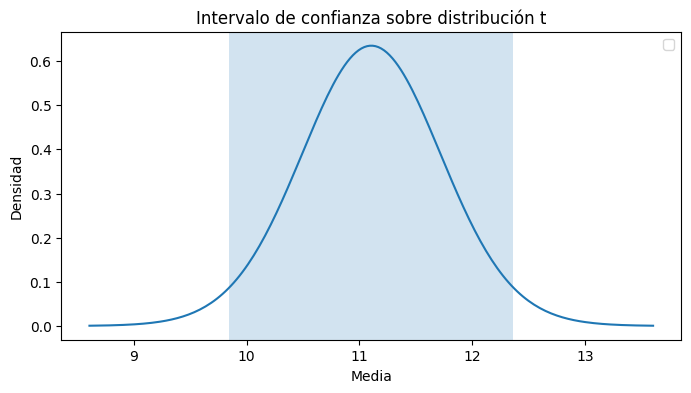

In [7]:
# --- distribución t para graficar ---
x_plot = np.linspace(media_muestral - 4*error_estandar, media_muestral + 4*error_estandar, 200)
y_plot = stats.t.pdf((x_plot - media_muestral) / error_estandar, grados_libertad) / error_estandar

# --- gráfico ---
plt.figure(figsize=(8, 4))

plt.plot(x_plot, y_plot)

# intervalo sombreado
plt.axvspan(limite_inf, limite_sup, alpha=0.2)

plt.title("Intervalo de confianza sobre distribución t")
plt.xlabel("Media")
plt.ylabel("Densidad")

plt.legend()
plt.show()

### Otró método de inferencia con menos líneas

In [8]:
# datos
x = muestra["nota_1er_sem"]

# objeto estadístico
desc = sms.DescrStatsW(x)

# intervalo de confianza del 95%
ic_inf, ic_sup = desc.tconfint_mean(alpha=0.05)
print(ic_inf.round(4), ic_sup.round(4))

9.8457 12.3655


La universidad afirma que el promedio de notas del primer semestre de los estudiantes es 12 puntos.

Con un nivel de significancia del 5%, determine si existe evidencia estadística para afirmar que el promedio real de notas es distinto de 12.

In [9]:
# datos de la muestra
x = muestra["nota_1er_sem"]

# objeto estadístico
desc = sms.DescrStatsW(x)

# test t para media poblacional
t_stat, p_value, df = desc.ttest_mean(12.3)

print("t =", t_stat)
print("p-value =", p_value)
print("gl =", df)

alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

t = -1.9118577486429063
p-value = 0.06257263680428972
gl = 43.0
No se rechaza H0


## Bootstrapping

In [10]:
n = 44
muestra = df_poblacion.sample(n=n, random_state=123)
media_muestra = muestra.mean()
print("MUESTRA BASE")
print(f"Cantidad total de alumnos en la muestra: {len(muestra)}")
print(f"Media real de la muestra: {media_muestra:}")
muestra.describe()

MUESTRA BASE
Cantidad total de alumnos en la muestra: 44
Media real de la muestra: nota_1er_sem    11.105614
dtype: float64


,nota_1er_sem
count,44.000000
mean,11.105614
std,4.143959
min,0.000000
25%,11.437500
50%,12.373095
75%,13.041667
max,14.666667


In [11]:
desc_muestra = muestra["nota_1er_sem"].describe()
tabla = pd.concat([desc_poblacion, desc_muestra], axis=1).round(2)
tabla.columns = ["Población", "Muestra"]
tabla

,Población,Muestra
count,4424.00,44.00
mean,10.64,11.11
std,4.84,4.14
min,0.00,0.00
25%,11.00,11.44
50%,12.29,12.37
75%,13.40,13.04
max,18.88,14.67


In [12]:
B = 1000
medias_bootstrap = []  # generamos el objeto donde se guardarán las medias

for i in range(B):

    muestra_boot = muestra["nota_1er_sem"].sample(
        n=len(muestra),
        replace=True
    )
    media_boot = muestra_boot.mean()  # Calculamos la media de esta muestra bootstrap.
    medias_bootstrap.append(media_boot)

# Convertimos la lista en un array de numpy para facilitar los cálculos posteriores (media, desvío, etc.)
medias_bootstrap = np.array(medias_bootstrap)

In [13]:
medias_bootstrap[:10]

array([10.44977814, 10.82666126, 11.4182197 , 11.07720779, 10.70205087,
       10.93448052, 11.97199675, 10.31607684, 12.06510552, 11.51649892])

Cada uno de estos valores representa una media que podríamos haber obtenido si repitiéramos el muestreo.

Este gráfico aproxima la distribución muestral de la media, que normalmente no podemos observar directamente.

In [14]:
# Calculamos los límites del intervalo de confianza bootstrap (95%)
ic_inf = np.percentile(medias_bootstrap, 2.5)
ic_sup = np.percentile(medias_bootstrap, 97.5)

print("IC 95% inferior:", ic_inf)
print("IC 95% superior:", ic_sup)

IC 95% inferior: 9.829327110590908
IC 95% superior: 12.258760958596591


In [15]:
media_global = medias_bootstrap.mean()
media_global

np.float64(11.143985221855)

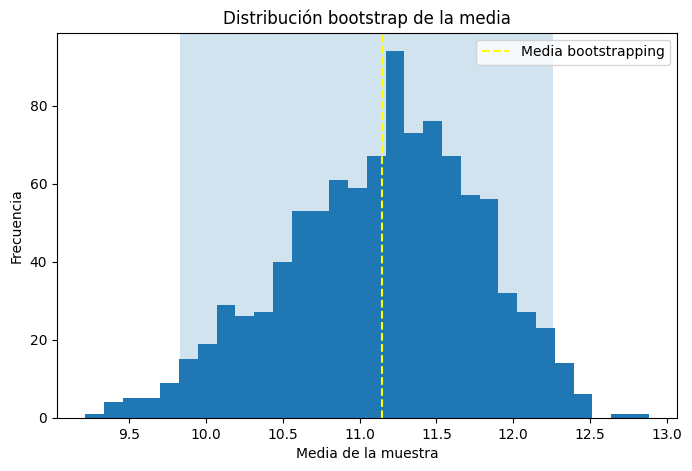

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(medias_bootstrap, bins=30)

# media bootstrap
plt.axvline(medias_bootstrap.mean(), color='yellow', linestyle="--", label="Media bootstrapping")

# IC sombreado
plt.axvspan(ic_inf, ic_sup, alpha=0.2)

plt.xlabel("Media de la muestra")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap de la media")

plt.legend()
plt.show()

In [17]:
# Desvío estándar bootstrap (estimación del error estándar del estimador)
desvio_bootstrap = np.std(medias_bootstrap, ddof=1).round(4)  # ddof=1 es la corrección de los grados de libertad (N-1)
print("Desvío estándar bootstrap:", desvio_bootstrap)

Desvío estándar bootstrap: 0.6324


Es decir, mide cuánto variaría la media si repitiéramos el muestreo muchas veces.

In [18]:
error_teorico = muestra["nota_1er_sem"].std(ddof=1) / np.sqrt(len(muestra))
print("Error estándar teórico:", error_teorico)
print("Error estándar bootstrap:", desvio_bootstrap)

Error estándar teórico: 0.6247252565457925
Error estándar bootstrap: 0.6324


Ambos valores son muy parecidos.

### Otro camino por Statsmodels

In [19]:
x = muestra["nota_1er_sem"].values

resultado = bootstrap((x,),
                      np.mean,
                      confidence_level=0.95,
                      n_resamples=1000,
                      random_state=42)

print(resultado.confidence_interval)

ConfidenceInterval(low=np.float64(9.659019719276163), high=np.float64(12.110587484937529))


In [20]:
# recuperamos la distribución bootstrap de la media
dist_bootstrap_S = resultado.bootstrap_distribution

# media bootstrap
media_bootstrap_S = np.mean(dist_bootstrap_S).round(4)

# error estándar bootstrap
se_boot_S = np.std(dist_bootstrap_S, ddof=1).round(4)

print("Media bootstrap por Statsmodels:", media_bootstrap_S)
print("Error estándar bootstrap por Statsmodels:", se_boot_S)

Media bootstrap por Statsmodels: 11.0979
Error estándar bootstrap por Statsmodels: 0.63


In [21]:
ic_infe = np.percentile(dist_bootstrap_S, 2.5)
ic_supe = np.percentile(dist_bootstrap_S, 97.5)

print("IC 95% inferior:", ic_infe)
print("IC 95% superior:", ic_supe)

IC 95% inferior: 9.774388122687501
IC 95% superior: 12.213398336323863


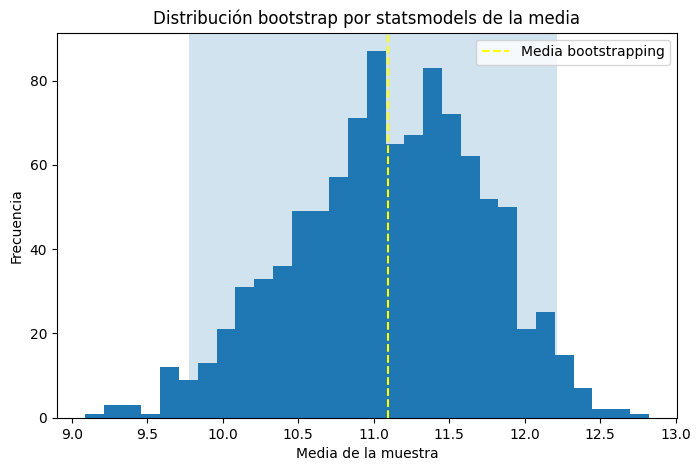

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(dist_bootstrap_S, bins=30)

# media bootstrap
plt.axvline(media_bootstrap_S, color='yellow', linestyle="--", label="Media bootstrapping")

# IC sombreado
plt.axvspan(ic_infe, ic_supe, alpha=0.2)

plt.xlabel("Media de la muestra")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap por statsmodels de la media")

plt.legend()
plt.show()